In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# regression modules
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# classification modules
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [33]:
df = pd.read_csv('data/processed/spotify_data_cleaned.csv')

# dropping the idenifier columns since no prediction can be made on them.

df = df.drop(columns=["track_id", "artists", "album_name", "track_name"], errors = 'ignore')

# encoding 'explicit' as binary integer, 1-true, 0-false
df['explicit'] = df['explicit'].astype(int)

TARGET = 'popularity'

NUMERIC_FEATURES = [
    "danceability", "energy", "loudness", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo", "duration_min",
    "explicit", "mode"
]

OHE_INT_FEATURES = ["key", "time_signature"]
OHE_STR_FEATURES = ["track_genre"]

x = df[NUMERIC_FEATURES + OHE_INT_FEATURES + OHE_STR_FEATURES]
y = df[TARGET]

print(f"Dataset: {x.shape[0]:,} songs with {x.shape[1]:,} features each.")
print(f"Popularity - min: {y.min()}, max: {y.max()}, mean: {y.mean():.2f}, median: {y.median()}, std: {y.std():.2f}")


Dataset: 97,980 songs with 15 features each.
Popularity - min: 1, max: 100, mean: 38.67, median: 39.0, std: 19.20


In [34]:
# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), OHE_INT_FEATURES),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), OHE_STR_FEATURES)
    ], remainder='drop'
)

print("Preprocessing pipeline created successfully.")
print(f"  • Scaled numeric : {len(NUMERIC_FEATURES)} features")
print(f"  • OHE string     : {OHE_STR_FEATURES}  (114 genres → 114 columns)")
print(f"  • OHE integer    : {OHE_INT_FEATURES}   (key × 12 + time_sig × 5)")

Preprocessing pipeline created successfully.
  • Scaled numeric : 12 features
  • OHE string     : ['track_genre']  (114 genres → 114 columns)
  • OHE integer    : ['key', 'time_signature']   (key × 12 + time_sig × 5)


In [35]:
# regression, train/test split.

y_log = np.log1p(y)

y_bins = pd.cut(y, bins = [0,30,60,100], labels = ['Low', 'Medium', 'High'])

x_train, x_test, y_train_raw, y_test_raw = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y_bins)

y_train_log = np.log1p(y_train_raw)
y_test_log = np.log1p(y_test_raw)


print(f"Train: {len(x_train):,} | Test: {len(x_test):,}")
print(f"\nTier distribution in train set:")
print(pd.cut(y_train_raw, bins= [0,30,60,100], labels = ["Low", "Medium", "High"]).value_counts(normalize= True).sort_index().round(3))


Train: 78,384 | Test: 19,596

Tier distribution in train set:
popularity
Low       0.365
Medium    0.497
High      0.138
Name: proportion, dtype: float64


Ridge Regression (log-transformed target): 
  RMSE: 16.67
  MAE: 11.59
  R²: 0.241


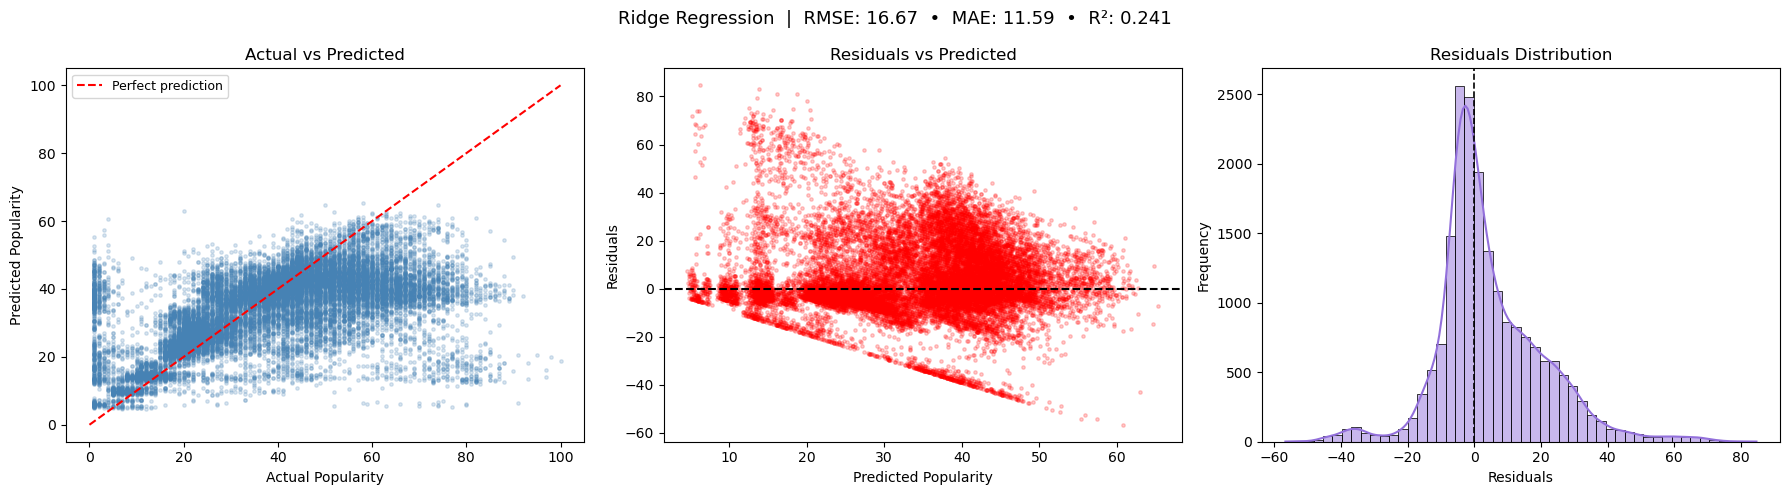

In [36]:
# regression baseline, ridge.

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge_pipeline.fit(x_train, y_train_log)
y_pred_log = ridge_pipeline.predict(x_test)
y_pred_ridge = np.expm1(y_pred_log)

rmse_ridge = np.sqrt(mean_squared_error(y_test_raw, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test_raw, y_pred_ridge)
r2_ridge = r2_score(y_test_raw, y_pred_ridge)
print("Ridge Regression (log-transformed target): ")
print(f"  RMSE: {rmse_ridge:.2f}")
print(f"  MAE: {mae_ridge:.2f}")
print(f"  R²: {r2_ridge:.3f}")


residuals_ridge = y_test_raw - y_pred_ridge
fig, axes = plt.subplots(1,3,figsize=(18,5))
fig.suptitle(f"Ridge Regression  |  RMSE: {rmse_ridge:.2f}  •  MAE: {mae_ridge:.2f}  •  R²: {r2_ridge:.3f}", fontsize=13)

axes[0].scatter(y_test_raw, y_pred_ridge, alpha = 0.2, s = 6, color = 'steelblue')
axes[0].plot([0,100], [0,100], "r--", linewidth=1.5, label = "Perfect prediction")
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Popularity")
axes[0].set_ylabel("Predicted Popularity")
axes[0].legend(fontsize = 9)


# residuals vs predicted
axes[1].scatter(y_pred_ridge, residuals_ridge, alpha = 0.2, s=6, color = 'red')
axes[1].axhline(0, color = "black", linewidth=1.5, linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted Popularity")
axes[1].set_ylabel("Residuals")

# residuals distribution
sns.histplot(residuals_ridge, bins=50, kde=True, color="mediumpurple", ax=axes[2])
axes[2].axvline(0, color = 'black', linewidth = 1.2, linestyle = "--")
axes[2].set_title("Residuals Distribution")
axes[2].set_xlabel("Residuals")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


Random Forest Regression (log-transformed target):
  Train R²  : 0.640  (overfitting gap = 0.263)
  OOB R²    : 0.452   (out-of-bag estimate)
  Test  R²  : 0.376
  RMSE      : 15.11
  MAE       : 10.31


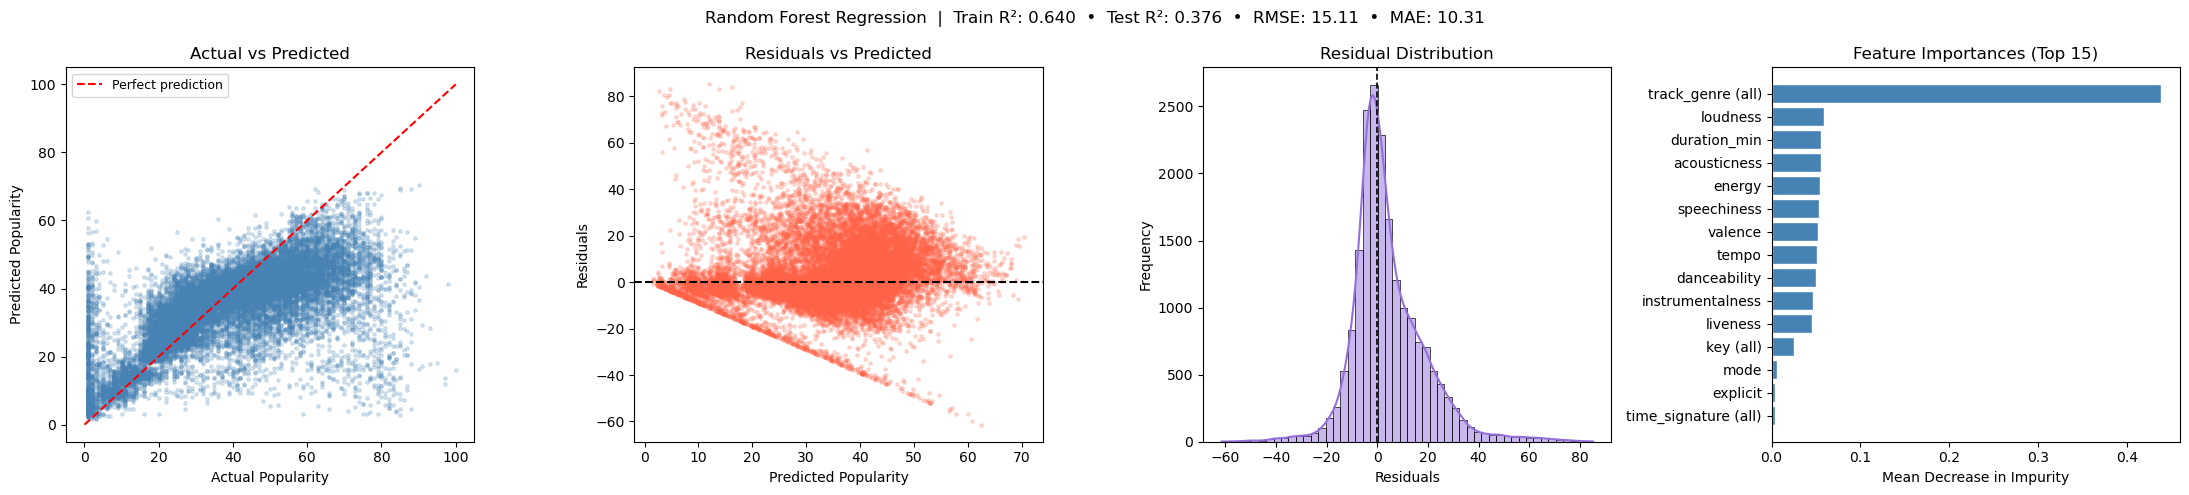

In [37]:
# random forest regression

rf_reg_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=None,        
        min_samples_leaf=5,
        max_features=0.3,      
        oob_score=True,
        n_jobs=-1,
        random_state=42
    ))
])

rf_reg_pipeline.fit(x_train, y_train_log)

# test metrics
y_pred_rf_reg  = np.expm1(rf_reg_pipeline.predict(x_test))
rmse_rf_reg    = np.sqrt(mean_squared_error(y_test_raw, y_pred_rf_reg))
mae_rf_reg     = mean_absolute_error(y_test_raw, y_pred_rf_reg)
r2_rf_reg      = r2_score(y_test_raw, y_pred_rf_reg)

# train metrics — detect overfitting/underfitting gap
y_pred_rf_train = np.expm1(rf_reg_pipeline.predict(x_train))
r2_train        = r2_score(y_train_raw, y_pred_rf_train)
oob_r2          = rf_reg_pipeline.named_steps['model'].oob_score_

print("Random Forest Regression (log-transformed target):")
print(f"  Train R²  : {r2_train:.3f}  (overfitting gap = {r2_train - r2_rf_reg:.3f})")
print(f"  OOB R²    : {oob_r2:.3f}   (out-of-bag estimate)")
print(f"  Test  R²  : {r2_rf_reg:.3f}")
print(f"  RMSE      : {rmse_rf_reg:.2f}")
print(f"  MAE       : {mae_rf_reg:.2f}")


residuals_rf_reg = y_test_raw - y_pred_rf_reg

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    f"Random Forest Regression  |  Train R²: {r2_train:.3f}  •  Test R²: {r2_rf_reg:.3f}  •  RMSE: {rmse_rf_reg:.2f}  •  MAE: {mae_rf_reg:.2f}",
    fontsize=12
)

# actual vs predicted
axes[0].scatter(y_test_raw, y_pred_rf_reg, alpha=0.2, s=6, color='steelblue')
axes[0].plot([0, 100], [0, 100], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Popularity")
axes[0].set_ylabel("Predicted Popularity")
axes[0].legend(fontsize=9)

# residuals vs predicted
axes[1].scatter(y_pred_rf_reg, residuals_rf_reg, alpha=0.2, s=6, color='tomato')
axes[1].axhline(0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted Popularity")
axes[1].set_ylabel("Residuals")

# residual distribution
sns.histplot(residuals_rf_reg, bins=50, kde=True, color="mediumpurple", ax=axes[2])
axes[2].axvline(0, color='black', linewidth=1.2, linestyle="--")
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residuals")
axes[2].set_ylabel("Frequency")

# feature importances
rf_model  = rf_reg_pipeline.named_steps['model']
prep_fit  = rf_reg_pipeline.named_steps['prep']

feat_names = (
    NUMERIC_FEATURES
    + list(prep_fit.named_transformers_['cat'].get_feature_names_out(OHE_INT_FEATURES))
    + list(prep_fit.named_transformers_['ohe'].get_feature_names_out(OHE_STR_FEATURES))
)
importances = pd.Series(rf_model.feature_importances_, index=feat_names)

# aggregate OHE groups into single entries
agg = importances[
    ~importances.index.str.startswith(("track_genre_", "key_", "time_signature_"))
].copy()
agg["track_genre (all)"]   = importances[importances.index.str.startswith("track_genre_")].sum()
agg["key (all)"]           = importances[importances.index.str.startswith("key_")].sum()
agg["time_signature (all)"]= importances[importances.index.str.startswith("time_signature_")].sum()
agg = agg.sort_values(ascending=True).tail(15)

axes[3].barh(agg.index, agg.values, color="steelblue", edgecolor="white")
axes[3].set_title("Feature Importances (Top 15)")
axes[3].set_xlabel("Mean Decrease in Impurity")

plt.tight_layout()
plt.show()


Hist Gradient Boosting Regression (log-transformed target):
  RMSE: 16.11
  MAE: 11.25
  R²: 0.291


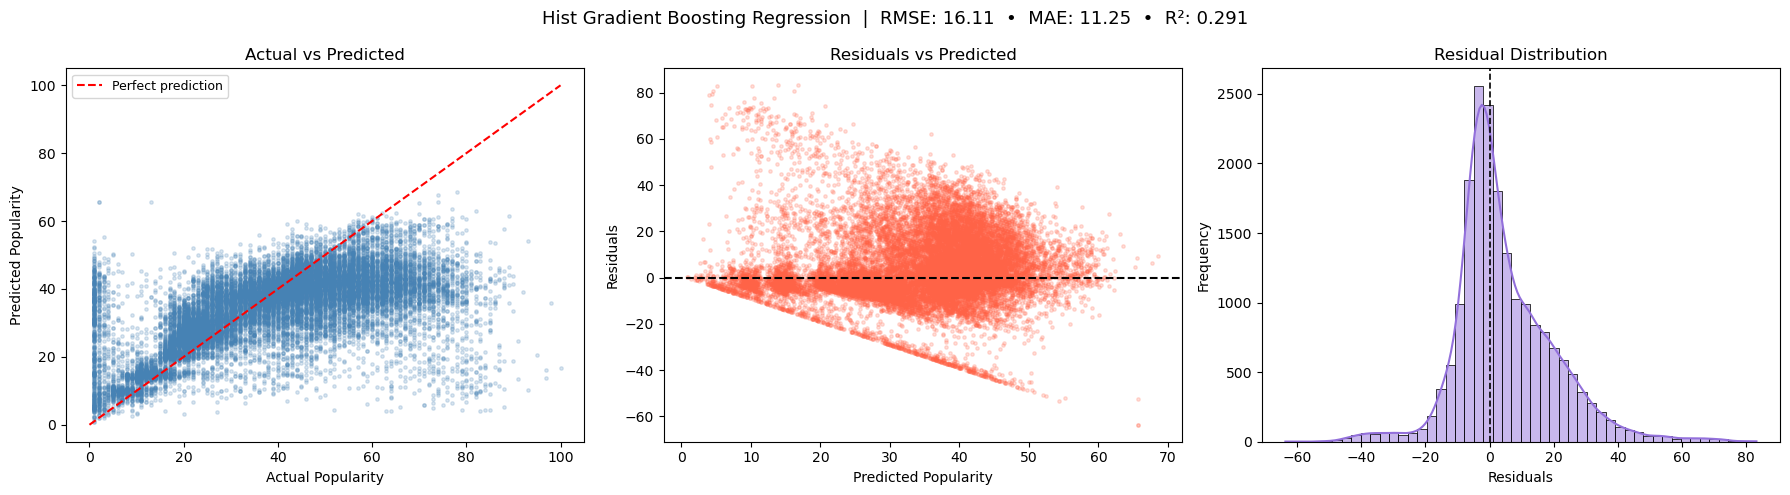

In [41]:
# regression, hist gradient boosting

hgb_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', HistGradientBoostingRegressor(
        max_iter=200,
        max_depth=None,
        min_samples_leaf=5,
        random_state=42
    ))
])

hgb_reg_pipe.fit(x_train, y_train_log)
y_pred_hgb_reg = np.expm1(hgb_reg_pipe.predict(x_test))
rmse_hgb_reg = np.sqrt(mean_squared_error(y_test_raw, y_pred_hgb_reg))
mae_hgb_reg = mean_absolute_error(y_test_raw, y_pred_hgb_reg)
r2_hgb_reg = r2_score(y_test_raw, y_pred_hgb_reg)

print("Hist Gradient Boosting Regression (log-transformed target):")
print(f"  RMSE: {rmse_hgb_reg:.2f}")
print(f"  MAE: {mae_hgb_reg:.2f}")
print(f"  R²: {r2_hgb_reg:.3f}")

# visualization for HGB regression
residuals_hgb_reg = y_test_raw - y_pred_hgb_reg
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Hist Gradient Boosting Regression  |  RMSE: {rmse_hgb_reg:.2f}  •  MAE: {mae_hgb_reg:.2f}  •  R²: {r2_hgb_reg:.3f}", fontsize=13)     
axes[0].scatter(y_test_raw, y_pred_hgb_reg, alpha=0.2, s=6, color='steelblue')
axes[0].plot([0, 100], [0, 100], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Popularity")
axes[0].set_ylabel("Predicted Popularity")
axes[0].legend(fontsize=9)

axes[1].scatter(y_pred_hgb_reg, residuals_hgb_reg, alpha=0.2, s=6, color='tomato')
axes[1].axhline(0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted Popularity")
axes[1].set_ylabel("Residuals")

sns.histplot(residuals_hgb_reg, bins=50, kde=True, color="mediumpurple", ax=axes[2])
axes[2].axvline(0, color='black', linewidth=1.2, linestyle="--")
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residuals")
axes[2].set_ylabel("Frequency")
plt.tight_layout()
plt.show()